# European Airport Performance Analyzer

## 1. Dataset Overview

In [ ]:
# ── Imports ──────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import os
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

In [ ]:
# Load .env from /streamlit/
load_dotenv(find_dotenv())


# Connection to DB
def get_engine():
    url = URL.create(
        "postgresql+psycopg2",
        username=os.environ["DB_USER"],
        password=os.environ["DB_PASSWORD"],
        host=os.environ["DB_HOST"],
        port=os.environ["DB_PORT"],
        database=os.environ["DB_NAME"],
    )
    return create_engine(url, pool_pre_ping=True, pool_recycle=1800)

def run_query(query, params=None):
    with get_engine().connect() as conn:
        return pd.read_sql(text(query), conn, params=params or {})

def query(sql, **kwargs):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn, **kwargs)
    

table_queries = {
    'fact_flight':          'SELECT COUNT(*) AS n FROM fact_flight',
    'fact_flight_event':    'SELECT COUNT(*) AS n FROM fact_flight_event',
    'fact_airport_traffic': 'SELECT COUNT(*) AS n FROM fact_airport_traffic',
    'fact_airport_delay':   'SELECT COUNT(*) AS n FROM fact_airport_delay',
    'fact_enroute_delay':   'SELECT COUNT(*) AS n FROM fact_enroute_delay',
    'fact_weather':         'SELECT COUNT(*) AS n FROM fact_weather',
    'dim_airport':          'SELECT COUNT(*) AS n FROM dim_airport',
    'dim_airline':          'SELECT COUNT(*) AS n FROM dim_airline',
}

rows = []
for tbl, sql in table_queries.items():
    r = run_query(sql).iloc[0]
    rows.append({
        'Table': tbl,
        'Rows':  int(r['n']),
    })

df_overview = pd.DataFrame(rows)

print('=' * 41)
print(f"  {'Table':<26} {'Rows':>12}")
print('=' * 41)
for _, r in df_overview.iterrows():
    print(f"  {r['Table']:<26} {r['Rows']:>12,.0f}")
print('=' * 41)
print(f"  {'TOTAL':<26} {df_overview['Rows'].sum():>12,.0f}")

  Table                              Rows
  fact_flight                  62,533,087
  fact_flight_event           159,018,422
  fact_airport_traffic          1,129,232
  fact_airport_delay            1,017,228
  fact_enroute_delay              156,304
  fact_weather                 38,164,896
  dim_airport                      85,289
  dim_airline                       5,853
  TOTAL                       262,110,311


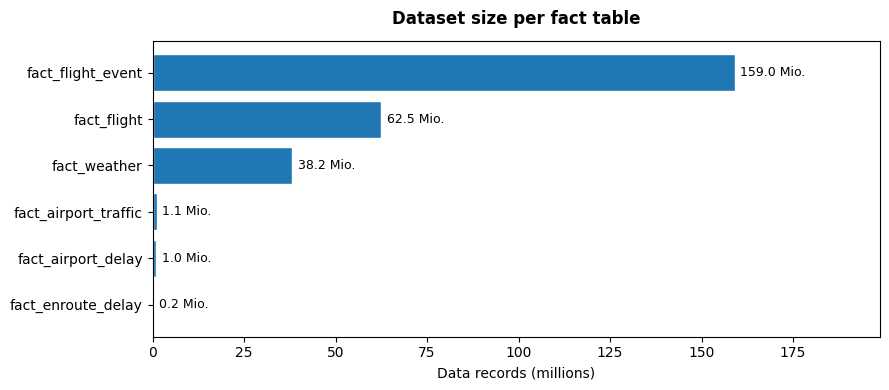

In [25]:
fact_df = df_overview[df_overview['Table'].str.startswith('fact_')].sort_values('Rows')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(fact_df['Table'], fact_df['Rows'] / 1e6, edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'{x:.1f} Mio.', padding=4, fontsize=9)
ax.set_xlabel('Data records (millions)')
ax.set_title('Dataset size per fact table', fontweight='bold', pad=12)
ax.set_xlim(0, fact_df['Rows'].max() / 1e6 * 1.25)

plt.tight_layout()
plt.show()

## 2. Europe’s Largest Airports
Basis: Eurocontrol Airport Traffic, 2019–2024

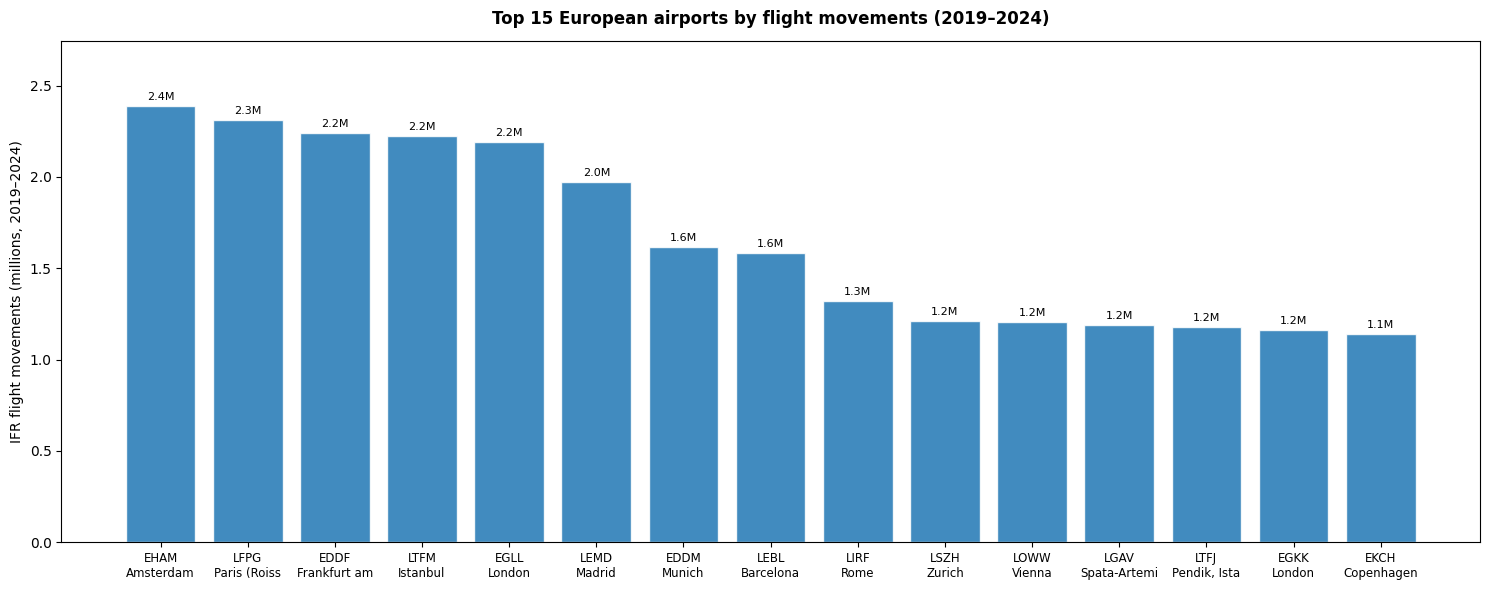

In [ ]:
df_airports = run_query("""
SELECT
    t.apt_icao,
    a.name            AS airport_name,
    a.iso_country     AS country,
    a.municipality,
    SUM(t.flt_tot_1)  AS total_movements,
    SUM(t.flt_dep_1)  AS departures,
    SUM(t.flt_arr_1)  AS arrivals,
    ROUND(AVG(t.flt_tot_1), 0) AS avg_daily
FROM fact_airport_traffic t
JOIN dim_airport a ON t.apt_icao = a.ident
WHERE EXTRACT(year FROM t.flt_date) BETWEEN 2019 AND 2024
  AND t.flt_tot_1 > 0
GROUP BY t.apt_icao, a.name, a.iso_country, a.municipality
ORDER BY total_movements DESC
LIMIT 20
"""
)


top15 = df_airports.head(15).copy()
top15['label'] = top15['apt_icao'] + '\n' + top15['municipality'].str[:12]

fig, ax = plt.subplots(figsize=(15, 6))
bars = ax.bar(top15['label'], top15['total_movements'] / 1e6,
              alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'{x:.1f}M', padding=3, fontsize=8)
ax.set_ylabel('IFR flight movements (millions, 2019–2024)')
ax.set_title('Top 15 European airports by flight movements (2019–2024)',
             fontweight='bold', pad=12)
ax.set_ylim(0, top15['total_movements'].max() / 1e6 * 1.15)
plt.xticks(fontsize=8.5)

plt.tight_layout()
plt.show()

## 3. Airport Map

### 3.1 Flight Movements

In [ ]:
df_map = run_query("""
SELECT
    t.apt_icao,
    a.name            AS airport_name,
    a.municipality,
    a.iso_country     AS country,
    a.latitude_deg    AS lat,
    a.longitude_deg   AS lon,
    SUM(t.flt_tot_1)  AS total_movements
FROM fact_airport_traffic t
JOIN dim_airport a ON t.apt_icao = a.ident
WHERE EXTRACT(year FROM t.flt_date) = 2025
  AND t.flt_tot_1 > 0
  AND a.latitude_deg  BETWEEN 35 AND 72     -- Europe-Bounding-Box
  AND a.longitude_deg BETWEEN -25 AND 45
  AND a.type IN ('large_airport', 'medium_airport')
GROUP BY t.apt_icao, a.name, a.municipality, a.iso_country, a.latitude_deg, a.longitude_deg
HAVING SUM(t.flt_tot_1) > 500
ORDER BY total_movements DESC
"""
)

df_map['airport_name'] = df_map['airport_name'].apply(
    lambda x: x.encode('latin-1').decode('utf-8') if isinstance(x, str) else x
)

fig = px.scatter_geo(
    df_map,
    lat='lat',
    lon='lon',
    size='total_movements',
    color='total_movements',
    color_continuous_scale='Blues',
    hover_name='airport_name',
    hover_data={
        'apt_icao':         True,
        'municipality':     True,
        'country':          True,
        'total_movements':  ':,.0f',
        'lat':              False,
        'lon':              False,
    },
    size_max=40,
    scope='europe',
    title='European airports by IFR flight movements (2025)',
    labels={'total_movements': 'Flight movements'},
)
fig.update_layout(
    coloraxis_colorbar=dict(title='Flight movements'),
    geo=dict(
        showland=True,        landcolor='#e8e8e8',
        showocean=True,       oceancolor='#dceefb',
        showcoastlines=True,  coastlinecolor='white',
        showcountries=True,   countrycolor='white',      
        projection_type='natural earth',
        center=dict(lat=52, lon=12),
        lataxis_range=[34, 72],
        lonaxis_range=[-25, 45],
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    height=550,
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### 3.2 ATFM delay per arrival

In [ ]:
df_map_delay = run_query("""
SELECT
    d.apt_icao,
    a.name            AS airport_name,
    a.municipality,
    a.iso_country     AS country,
    a.latitude_deg    AS lat,
    a.longitude_deg   AS lon,
    SUM(d.flt_arr_1)                                          AS total_arrivals,
    SUM(d.dly_apt_arr_1)                                      AS total_delay_min,
    ROUND(SUM(d.dly_apt_arr_1) / NULLIF(SUM(d.flt_arr_1), 0), 3) AS delay_per_arrival
FROM fact_airport_delay d
JOIN dim_airport a ON d.apt_icao = a.ident
WHERE EXTRACT(year FROM d.flt_date) = 2025
  AND d.dly_apt_arr_1 > 0
  AND a.latitude_deg  BETWEEN 35 AND 72
  AND a.longitude_deg BETWEEN -25 AND 45
  AND a.type IN ('large_airport', 'medium_airport')
GROUP BY d.apt_icao, a.name, a.municipality, a.iso_country,
         a.latitude_deg, a.longitude_deg
HAVING SUM(d.flt_arr_1) > 365
ORDER BY delay_per_arrival DESC
"""
)

df_map_delay['airport_name'] = df_map_delay['airport_name'].apply(
    lambda x: x.encode('latin-1').decode('utf-8') if isinstance(x, str) else x
)

fig2 = px.scatter_geo(
    df_map_delay,
    lat='lat',
    lon='lon',
    size='delay_per_arrival',
    color='delay_per_arrival',
    color_continuous_scale='Reds',
    hover_name='airport_name',
    hover_data={
        'apt_icao':          True,
        'municipality':      True,
        'country':           True,
        'delay_per_arrival': ':.3f',
        'total_arrivals':    ':,.0f',
        'lat':               False,
        'lon':               False,
    },
    size_max=40,
    scope='europe',
    title='ATFM delay per arrival by airport (2025)',
    labels={'delay_per_arrival': 'min / arrival'},
)
fig2.update_layout(
    coloraxis_colorbar=dict(title='min / arrival'),
    geo=dict(
        showland=True,       landcolor='#e8e8e8',
        showocean=True,      oceancolor='#dceefb',
        showcoastlines=True, coastlinecolor='white',
        showcountries=True,  countrycolor='white',
        projection_type='natural earth',
        center=dict(lat=52, lon=12),
        lataxis_range=[34, 72],
        lonaxis_range=[-25, 45],
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    height=550,
)
fig2.show()

## 4. Enroute delay map

In [ ]:
df_choro = run_query("""
SELECT
    r.iso_country AS iso_a2,
    r.country_name,
    SUM(e.dly_ert_1) AS total_delay_min,
    SUM(e.flt_ert_1) AS total_flights,
    ROUND(SUM(e.dly_ert_1) / NULLIF(SUM(e.flt_ert_1), 0), 4) AS delay_per_flight,
    ROUND(SUM(e.flt_ert_1_dly_15)::NUMERIC
          / NULLIF(SUM(e.flt_ert_1), 0) * 100, 2) AS pct_delayed_15min,
    ROUND(SUM(e.dly_ert_c_1) / NULLIF(SUM(e.dly_ert_1), 0) * 100, 1) AS pct_atc_capacity,
    ROUND(SUM(e.dly_ert_s_1) / NULLIF(SUM(e.dly_ert_1), 0) * 100, 1) AS pct_atc_staffing,
    ROUND(SUM(e.dly_ert_w_1) / NULLIF(SUM(e.dly_ert_1), 0) * 100, 1) AS pct_weather,
    ROUND(SUM(e.dly_ert_m_1) / NULLIF(SUM(e.dly_ert_1), 0) * 100, 1) AS pct_military,
    ROUND(SUM(e.dly_ert_r_1) / NULLIF(SUM(e.dly_ert_1), 0) * 100, 1) AS pct_routeing
FROM fact_enroute_delay e
JOIN dim_entity_region r ON e.entity_name = r.entity_name
WHERE EXTRACT(year FROM e.flt_date) = 2025
  AND e.entity_type = 'ANSP (AUA)'
  AND e.dly_ert_1 IS NOT NULL
GROUP BY r.iso_country, r.country_name
ORDER BY delay_per_flight DESC
"""
)


# ISO-2 → ISO-3
ISO2_TO_ISO3 = {
    'AL':'ALB','AM':'ARM','AT':'AUT','AZ':'AZE','BA':'BIH','BE':'BEL',
    'BG':'BGR','BY':'BLR','CH':'CHE','CY':'CYP','CZ':'CZE','DE':'DEU',
    'DK':'DNK','EE':'EST','ES':'ESP','FI':'FIN','FR':'FRA','GB':'GBR',
    'GE':'GEO','GR':'GRC','HR':'HRV','HU':'HUN','IE':'IRL','IL':'ISR',
    'IS':'ISL','IT':'ITA','LT':'LTU','LU':'LUX','LV':'LVA','MD':'MDA',
    'ME':'MNE','MK':'MKD','MT':'MLT','NL':'NLD','NO':'NOR','PL':'POL',
    'PT':'PRT','RO':'ROU','RS':'SRB','SE':'SWE','SI':'SVN','SK':'SVK',
    'TR':'TUR','UA':'UKR',
}

df_choro['iso_a3'] = df_choro['iso_a2'].map(ISO2_TO_ISO3)

display(df_choro[['country_name','delay_per_flight','pct_atc_capacity',
                   'pct_atc_staffing','pct_weather','pct_military']].head(10))

,country_name,delay_per_flight,pct_atc_capacity,pct_atc_staffing,pct_weather,pct_military
0,France,1.9011,43.3,20.5,19.2,1.8
1,Iceland,1.5245,0.0,90.8,0.0,0.0
2,Serbia,1.1519,16.3,5.1,37.0,0.1
3,North Macedonia,1.1460,78.9,5.2,8.9,0.0
4,Spain,0.9941,69.4,1.2,23.1,0.0
5,Greece,0.9429,1.7,70.5,18.8,0.0
6,Croatia,0.9264,35.3,2.9,57.6,0.0
7,Germany,0.8897,48.8,9.0,39.0,1.4
8,Albania,0.8604,38.3,0.0,33.9,0.0
9,Hungary,0.8330,23.8,1.0,35.7,0.7


In [30]:
fig = px.choropleth(
    df_choro.dropna(subset=['iso_a3']),
    locations='iso_a3',
    color='delay_per_flight',
    hover_name='country_name',
    hover_data={
        'iso_a3':            False,
        'iso_a2':            False,
        'delay_per_flight':  ':.4f',
        'total_delay_min':   ':,.0f',
        'total_flights':     ':,.0f',
        'pct_delayed_15min': ':.1f',
        'pct_atc_capacity':  ':.1f',
        'pct_atc_staffing':  ':.1f',
        'pct_weather':       ':.1f',
        'pct_military':      ':.1f',
        'pct_routeing':      ':.1f',
    },
    color_continuous_scale='Reds',
    scope='europe',
    title='En-route ATFM delays per flight by country — ANSP/AUA level (2025)',
    labels={'delay_per_flight': 'min / flight'},
)
fig.update_layout(
    coloraxis_colorbar=dict(title='min / flight'),
    geo=dict(
        showland=True,       landcolor='#d0d0d0',
        showocean=True,      oceancolor='#dceefb',
        showcoastlines=True, coastlinecolor='white',
        showcountries=True,  countrycolor='white',
        projection_type='natural earth',
        center=dict(lat=52, lon=12),
        lataxis_range=[34, 72],
        lonaxis_range=[-25, 45],
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    height=550,
)

fig.show()

**Key takeaways:**

- **France** chronically lacks sufficient ATC capacity for the transit traffic crossing France, which serves as a central corridor between Northern and Southern Europe. Industrial action (strikes) frequently compounds the situation.
- **Iceland** manages a vast airspace with limited staff. Consequently, when weather restrictions or military activity occur there, almost every North Atlantic flight is affected.